In [11]:
""" This code is just to show that the gradient based VR algorithms explode before prox based ones. At the moment the experiment is still
on going to make different tests.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import rel_entr
import math

def kl_row_loss(z, b_i):
    z = max(z, 1e-15)
    if b_i <= 0:
        return z
    return b_i * np.log(b_i / z) - b_i + z


def kl_divergence_poisson(A, b, x):
    Ax = A @ x
    if np.any(Ax <= 0):
        return np.inf
    return np.mean([kl_row_loss(Ax[i], b[i]) for i in range(len(b))])


def row_gradient_diagonal(a_diag, b, x, i, eps=1e-15):
    """
    Gradient of the i-th component loss in the diagonal case A = diag(a_diag).

    For diagonal A, the row loss depends only on x_i and
        grad f_i(x) = (a_i - b_i / x_i) e_i.

    Parameters
    ----------
    a_diag : ndarray, shape (d,)
        Diagonal of A.
    b : ndarray, shape (d,)
        Data vector.
    x : ndarray, shape (d,)
        Current iterate.
    i : int
        Sampled coordinate / row index.
    eps : float
        Numerical safeguard for division.

    Returns
    -------
    ndarray, shape (d,)
        Sparse gradient vector with only coordinate i potentially nonzero.
    """
    grad = np.zeros_like(x)
    grad[i] = a_diag[i] - b[i] / max(x[i], eps)
    return grad

def full_gradient_diagonal(a_diag, b, x):
    """
    Full gradient for the diagonal Poisson/KL model.

    Parameters
    ----------
    a_diag : ndarray, shape (d,)
        Diagonal entries of A.
    b : ndarray, shape (d,)
        Data vector.
    x : ndarray, shape (d,)
        Current iterate.

    Returns
    -------
    grad : ndarray, shape (d,)
        Full gradient (average over rows).
    """
    d = len(a_diag)
    grad = np.zeros(d)

    for i in range(d):
        grad += row_gradient_diagonal(a_diag, b, x, i)

    return grad / d

def bregman_prox_diagonal(x, a_diag, b, correction, step_size, i, eps=1e-15):
    """
    Closed-form implicit Bregman update for the diagonal case.

    This solves the diagonal subproblem associated with h(x) = -sum_j log x_j.
    The vector `correction` plays the role of the variance-reduction term
    (stored gradient minus running average).

    Parameters
    ----------
    x : ndarray, shape (d,)
        Current positive iterate.
    a_diag : ndarray, shape (d,)
        Diagonal entries of A.
    b : ndarray, shape (d,)
        Data vector.
    correction : ndarray, shape (d,)
        Variance-reduction correction term.
    step_size : float
        Step size.
    i : int
        Active coordinate index.
    eps : float
        Numerical safeguard.

    Returns
    -------
    ndarray, shape (d,)
        Updated iterate.
    """
    x = np.asarray(x, dtype=float)
    a_diag = np.asarray(a_diag, dtype=float)
    b = np.asarray(b, dtype=float)
    correction = np.asarray(correction, dtype=float)

    # First apply the correction to all coordinates.
    denom = 1.0 / np.maximum(x, eps) - step_size * correction
    if np.any(denom <= eps):
        raise ValueError("Encountered a non-positive denominator in the Bregman update.")
    x_new = 1.0 / denom

    # Then update the active coordinate using the closed-form diagonal formula.
    denom_i = 1.0 / max(x[i], eps) - step_size * (correction[i] - a_diag[i])
    if denom_i <= eps:
        raise ValueError("Encountered a non-positive active-coordinate denominator.")
    x_new[i] = (1.0 + step_size * b[i]) / denom_i

    if np.any(x_new <= 0):
        raise ValueError("Non-positive iterate encountered. Try a smaller step size.")
    return x_new


def sapa_bregman_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    seed=None,
    use_vr=True,
    diminishing_step=False,
):
    """
    Implicit Bregman-SAPA / Bregman-SVRG-like method for diagonal A.

    Parameters
    ----------
    A : ndarray, shape (d, d)
        Diagonal forward operator.
    b : ndarray, shape (d,)
        Data vector.
    step_size : float
        Base step size.
    x0 : ndarray, shape (d,)
        Initial positive iterate.
    max_iter : int
        Number of stochastic iterations.
    seed : int or None
        Random seed for reproducibility.
    use_vr : bool
        If True, use the variance-reduction correction term.
        If False, use the plain implicit stochastic Bregman step.
    diminishing_step : bool
        If True, use min(step_size, 1/(t+1)).
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    if n_samples != n_features:
        raise ValueError("This implementation assumes a square diagonal matrix A.")
    a_diag = np.diag(A)

    x = np.asarray(x0, dtype=float).copy()
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive.")

    grad_table = np.zeros((n_samples, n_features))
    full_grad = grad_table.mean(axis=0)

    history = []
    history.append(kl_divergence_poisson(A, b, x) / n_features)
    base_step = step_size

    for t in range(max_iter):
        i = rng.integers(n_samples)
        try:
            current_step = base_step[t]
        except IndexError:
            current_step = base_step[-1]
        except TypeError:
            current_step = min(base_step, 1.0 / (t + 1)) if diminishing_step else base_step

        correction = grad_table[i] - full_grad if use_vr else np.zeros(n_features)

        # If it fails/explodes we don't stop we put a big value and continue
        try:
            x = bregman_prox_diagonal(x, a_diag, b, correction, current_step, i)
            history.append(kl_divergence_poisson(A, b, x) / n_features)
        except ValueError:
            history.append(10e2)
        stoch_grad = row_gradient_diagonal(a_diag, b, x, i)
        full_grad += (stoch_grad - grad_table[i]) / n_samples
        grad_table[i] = stoch_grad

    return history


def bregman_varag_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    seed=None,
    weighted_snapshot=True,
    L=1.0
):
    """
    Uniform-sampling explicit Burg-mirror VARAG in the diagonal case.

    Interface-compatible with the other methods:
        (A, b, step_size, x0, max_iter, ...)

    Theorem 1 of arXiv:1905.12412, except that sampling is kept uniform.

    Parameters
    ----------
    step_size : float
        Ignored, it is just to make the interface compatible with other method
    L : float or None
        Smoothness constant used in
            gamma_s = 1 / (3 * L * alpha_s)
        for the theorem-1 schedule.
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    if n_samples != n_features:
        raise ValueError("This implementation assumes a square diagonal matrix A.")

    a_diag = np.diag(A).astype(float)
    x0 = np.asarray(x0, dtype=float).copy()

    if np.any(x0 <= 0):
        raise ValueError("x0 must be strictly positive.")

    history = []
    history_epoch = []
    history.append(kl_divergence_poisson(A, b, x0) / n_features)
    history_epoch.append(kl_divergence_poisson(A, b, x0) / n_features)

    # Outer variables
    x_epoch = x0.copy()
    x_tilde_epoch = x0.copy()

    total_iter = 0
    s = 0
    m = n_samples
    list_step = []

    s0 = int(np.floor(np.log2(m))) + 1
    T_s0 = 2 ** (s0 - 1)

    exploded = False

    for i in range(max_iter):
        s += 1
        # ------------------------------------------------------------------
        # Theorem 1 parameters (uniformized adaptation)
        # ------------------------------------------------------------------
        if s <= s0:
            T = 2 ** (s - 1)
            alpha_s = 0.5
        else:
            T = T_s0
            alpha_s = 2.0 / (s - s0 + 4.0)

        p_s = 0.5

        gamma_s = 1.0 / (3.0 * L * alpha_s)


        # Snapshot and full gradient at snapshot
        x_tilde = x_tilde_epoch.copy()
        full_grad_tilde = full_gradient_diagonal(a_diag, b, x_tilde)

        # Start of epoch
        x_prev = x_epoch.copy()
        x_bar_prev = x_tilde.copy()

        weighted_sum = np.zeros_like(x0)
        weight_total = 0.0

        for t in range(1, T + 1):
            global_t = total_iter + 1
            list_step.append(gamma_s)
            current_step = gamma_s 

            # Uniform sampling
            i = rng.integers(n_samples)

            # Algorithm 1, line 7 with mu = 0
            x_md = (1.0 - alpha_s - p_s) * x_bar_prev + alpha_s * x_prev + p_s * x_tilde

            # Algorithm 1, line 8, but with uniform sampling
            grad_i_md = row_gradient_diagonal(a_diag, b, x_md, i)

            grad_i_tilde = row_gradient_diagonal(a_diag, b, x_tilde, i)
            G_t = grad_i_md - grad_i_tilde + full_grad_tilde

            # Explicit Burg mirror step
            denom = 1.0 / x_prev + current_step * G_t
            
            # If it fails/explodes we don't stop we put a big value and continue to see which one allows bigger step sizes
            if np.any(denom <= 0) or np.any(~np.isfinite(denom)):
                history.append(10e2)
                x_new = x_prev.copy()
                exploded = True
            else:
                x_new = 1.0 / denom
                history.append(kl_divergence_poisson(A, b, x_new) / n_features)

            # Algorithm 1, line 10
            x_bar_new = (1.0 - alpha_s - p_s) * x_bar_prev + alpha_s * x_new + p_s * x_tilde

            # Theorem 1 weights
            if weighted_snapshot:
                if t < T:
                    theta_t = (current_step / alpha_s) * (alpha_s + p_s)
                else:
                    theta_t = current_step / alpha_s
            else:
                theta_t = 1.0

            weighted_sum += theta_t * x_bar_new
            weight_total += theta_t

            x_prev = x_new
            x_bar_prev = x_bar_new
            total_iter += 1

        # End of epoch
        x_epoch = x_prev.copy()
        x_tilde_epoch = weighted_sum / weight_total
        if exploded:
            history_epoch.append(10e2)
            exploded = False
        else:
            history_epoch.append(kl_divergence_poisson(A, b, x_tilde_epoch) / n_features)
        
    return (history, history_epoch, list_step)


def run_experiment(
    A,
    b,
    x0,
    step_size,
    max_iter,
    method,
    n_runs=10,
    seed=42,
    **kwargs,
):
    """
    Run one method several times and stack the objective histories.

    Returns
    -------
    ndarray, shape (n_runs, max_iter + 1)
        Objective trajectories.
    """
    trajectories = []
    for run in range(n_runs):
        run_seed = None if seed is None else seed + 10 * run
        history = method(
            A=A,
            b=b,
            step_size=step_size,
            x0=x0,
            max_iter=max_iter,
            seed=run_seed,
            **kwargs,
        )
        trajectories.append(history)
    return np.vstack(trajectories)

def run_experiment_varag(
    A,
    b,
    x0,
    step_size,
    max_iter,
    method,
    n_runs=10,
    seed=42,
    **kwargs,
):
    """
    Run one method several times and stack the objective histories.

    Returns
    -------
    ndarray, shape (n_runs, max_iter + 1)
        Objective trajectories.
    """
    trajectories = []
    trajectories_epoch = []
    for run in range(n_runs):
        run_seed = None if seed is None else seed + 10 * run
        history, history_epoch, list_step = method(
            A=A,
            b=b,
            step_size=step_size,
            x0=x0,
            max_iter=max_iter,
            seed=run_seed,
            **kwargs,
        )
        trajectories.append(history)
        trajectories_epoch.append(history_epoch)
    return np.vstack(trajectories), np.vstack(trajectories_epoch), list_step


def plot_trajectories(
    results,
    n_samples,
    title="Diagonal Poisson inverse problem",
    shade=True,
    subtract_best=True,
    logy=True,
    figsize=(7, 5),
    stepsize=0.0
):
    """
    Plot mean trajectories with optional ±1 std shading.

    Parameters
    ----------
    results : dict[str, ndarray]
        Maps method names to arrays of shape (n_runs, T).
    n_samples : int
        Used to normalize the x-axis in epochs.
    shade : bool
        Whether to display a shaded ±1 std region.
    subtract_best : bool
        If True, subtract the best objective value observed across all runs.
    logy : bool
        If True, use logarithmic scale on the y-axis.
    """
    plt.figure(figsize=figsize)

    best_value = min(np.min(curves) for curves in results.values()) if subtract_best else 0.0

    for label, curves in results.items():
        mean_curve = curves.mean(axis=0) - best_value
        std_curve = curves.std(axis=0)
        x_axis = (n_samples/curves.shape[1])*np.arange(curves.shape[1]) #/ n_samples

        if subtract_best:
            mean_curve = np.maximum(mean_curve, 1e-16)

        line, = plt.plot(x_axis, mean_curve, label=label)
        if shade:
            lower = np.maximum(mean_curve - std_curve, 1e-16) if subtract_best else mean_curve - std_curve
            upper = mean_curve + std_curve
            plt.fill_between(x_axis, lower, upper, alpha=0.2, color=line.get_color())

    ylabel = r"$F(x^k)-F_\star$" if subtract_best else r"$F(x^k)$"
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.grid(False)
    plt.legend()
    plt.tight_layout()

def truncate(x, decimals=0):
    factor = 10.0 ** decimals
    return math.trunc(x * factor) / factor

In [12]:
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["font.size"] = 13
plt.rcParams["lines.linewidth"] = 3

# Problem setup: diagonal Poisson inverse problem
n = d = 256
seed = 42
rng = np.random.default_rng(seed)

a = np.random.rand(n)
A = np.diag(a)
x_star = np.random.rand(d)
Ax_true = A @ x_star

scale = 1.0  # increase noise
b = rng.poisson(np.maximum(Ax_true*scale, 1e-3)).astype(float)

# Positive initialization
x0 = rng.uniform(0.2, 1.0, size=d)

s0 = int(np.floor(np.log2(n))) + 1
max_epochs = 500

if max_epochs > s0:
    n_epochs = 500 - s0 # additional outer iteration beyond s0
else:
    n_epochs = 0

sum_ts = 2**s0 - 1

# A simple Lipschitz-like scale used in the original notebook
L_estimate = b.max()

# Toggle for shading in the plots
shade = False

# Number of independent runs
n_runs = 10

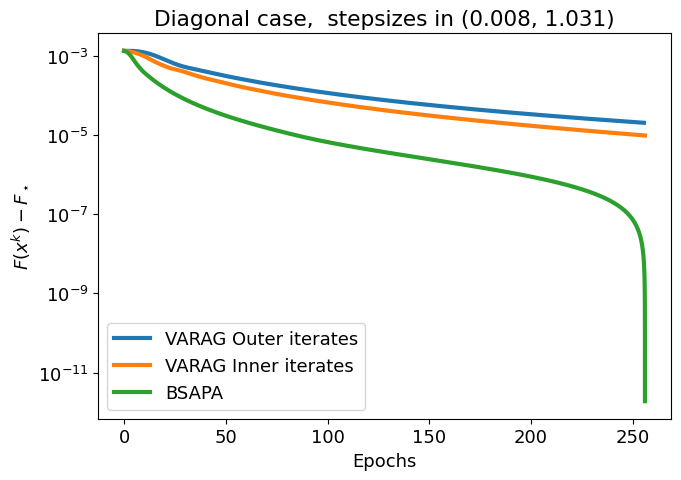

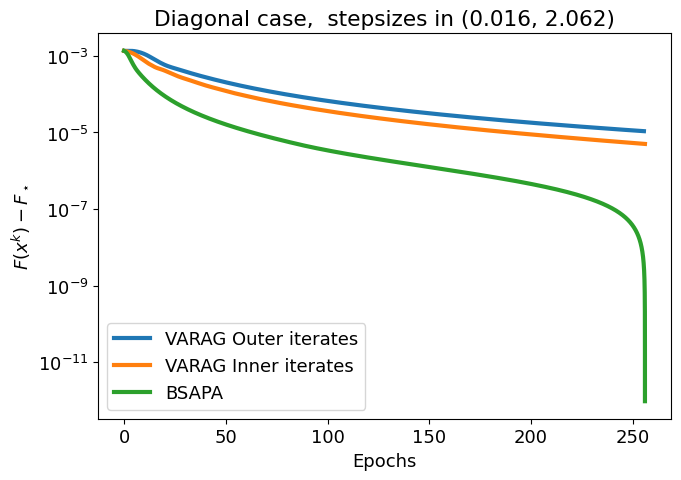

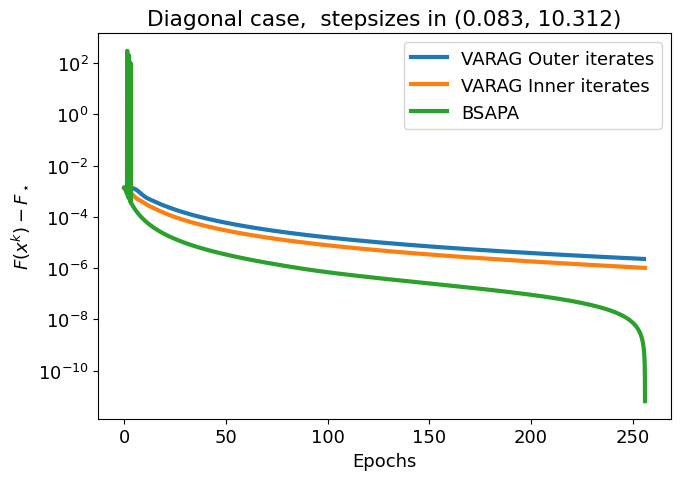

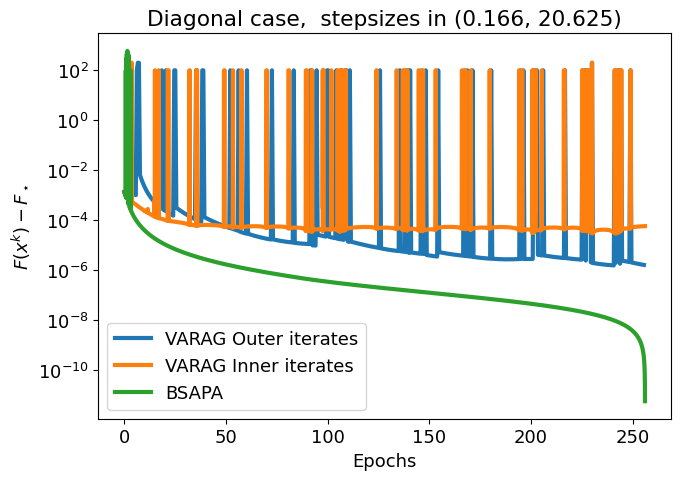

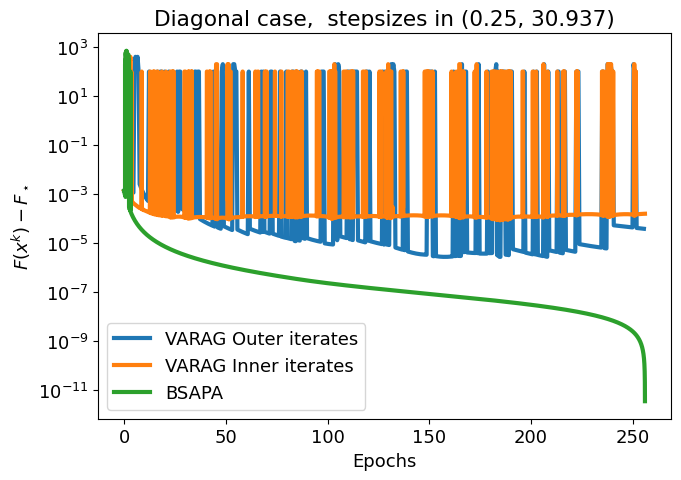

In [13]:
# Compare BSAPA vs Varag for several step sizes.
step_factors = [0.5, 1., 5., 10., 15.] 
# since L is an estimate of relatively smoothness constant wrt to the Burg entropy with tried several stepsizes

s0 = int(np.floor(np.log2(n))) + 1

sum_ts = 2**s0 - 1

all_results = {}

for factor in step_factors:

    history_varag, history_varag_epoch, list_step = run_experiment_varag(
            A,
            b,
            x0,
            step_size=None,
            max_iter= s0 + n_epochs,
            method=bregman_varag_diagonal,
            n_runs=n_runs,
            seed=seed,
            L= 20*L_estimate / factor                  # needed for gamma_s = 1/(3L alpha_s)
        )

    results = {
        "VARAG Outer iterates": history_varag_epoch,

        "VARAG Inner iterates": history_varag,
        
        "BSAPA": run_experiment(
            A,
            b,
            x0,
            step_size=list_step,
            max_iter = n*s0 + 2*sum_ts + 3*n_epochs*n - n, # we account for the additional gradient computation in Varag
            # max_iter = s0 + n_epochs,
            method=sapa_bregman_diagonal,
            n_runs=n_runs,
            seed=seed,
            use_vr=True,
            diminishing_step=False,
        ),
    }

    all_results[factor] = results

    plot_trajectories(
        results,
        n_samples=n,
        shade=shade,
        title=f"Diagonal case,  stepsizes in {truncate(list_step[0],3), truncate(list_step[-1],3)}",
    )
    # plt.savefig("Rebuttal/Plots/poisson_{}_diag_avg_all_bsapa_vs_bsaga.png".format(factor), bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()